###### Carleton School of Information Technology
### ITEC 5920 – Applied Deep Learning
### Winter 2026
### Instructor: Dr. Marzieh Amini
### Prepared by: Aziz Al-Najjar

sources:

https://www.datacamp.com/tutorial/k-nearest-neighbor-classification-scikit-learn

https://www.datacamp.com/tutorial/naive-bayes-scikit-learn

https://www.datacamp.com/tutorial/svm-classification-scikit-learn-python

https://towardsdatascience.com/logistic-regression-explained-and-implemented-in-python-880955306060

https://pub.towardsai.net/k-nearest-neighbors-knn-algorithm-tutorial-machine-learning-basics-ml-ec6756d3e0ac

https://pub.towardsai.net/naive-bayes-classifier-in-machine-learning-b0201684607c

https://pub.towardsai.net/support-vector-machine-svm-introduction-machine-learning-8c56b7da63f1

In this tutorial, we will discover how to implement different classification techniques, such as Logistic Regression, KNearest-neighbor, Support Vectors Machines, and Gaussian Naïve Bayes. 

As always, the first step is loading the commonly used libraries, numpy, pandas, and matplotlib

In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Dataset:
Througout the tutrial, the problem is going to be a standard binary classification problem. The dataset called the Pima Indians onset of diabetes problem. The problem has two classes and eight numeric input variables of varying scales.

You can learn more about the dataset here:

[Dataset File](https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv)

[Dataset Details](https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.names)

We will simplify columns by providing col_names to pandas read_csv() function

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
pima = pd.read_csv(url, header=None, names=col_names)
pima.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
#split dataset in features and target variable
feature_cols = ['pregnant', 'insulin', 'bmi', 'age','glucose','bp','pedigree']
X = pima[feature_cols] # Features
y = pima.label # Target variable

### Splitting Data

To understand model performance, dividing the dataset into a training set and a test set is a good strategy.

Let's split the dataset by using the function train_test_split(). You need to pass 3 parameters: features, target, and test_set size. Additionally, you can use random_state to select records randomly.

In [4]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

Here, the Dataset is broken into two parts in a ratio of 75:25. It means 75% data will be used for model training and 25% for model testing.

## Logistic Regression


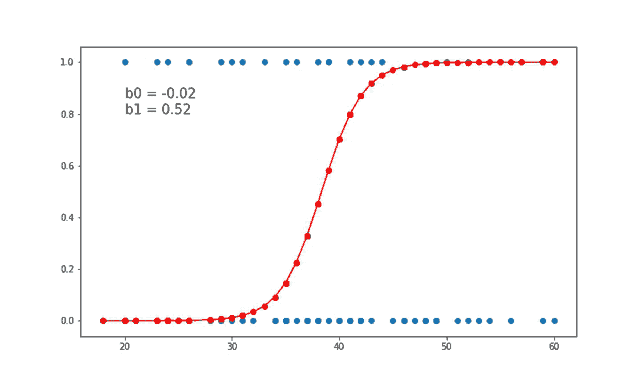


Linear regression predicts the value of some continuous, dependent variable. Whereas logistic regression predicts the probability of an event or class that is dependent on other factors. Thus the output of logistic regression always lies between 0 and 1. Because of this property it is commonly used for binary classification.

Best used for:

* Linear model
* Binary classification

### Logistic Regression using scikit-learn

First, import the Logistic Regression module and create a Logistic Regression classifier object using the LogisticRegression() function with random_state for reproducibility.

Then, fit your model on the train set using fit() and perform prediction on the test set using predict(). 

In [5]:
# import the module
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
logreg = LogisticRegression(random_state=16, max_iter=200)

# fit the model with data
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

Now lets evaluate the accuracy of the model

In [6]:
from sklearn import metrics

Accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy = {Accuracy}")

Logistic Regression Accuracy = 0.8177083333333334


Note that the accuracy could be improved by further modifying the model's hyperparameters and data pre-processing. However, for the scope of this tutorial, we will not dive into performance improvement 

## KNearest-neighbor 

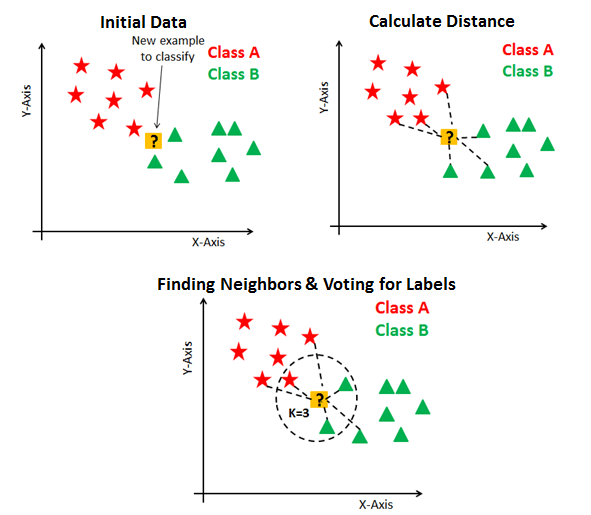

In KNN, K is the number of nearest neighbors. The number of neighbors is the core deciding factor. K is generally an odd number if the number of classes is 2. When K=1, then the algorithm is known as the nearest neighbor algorithm. This is the simplest case. Suppose P1 is the point, for which label needs to predict. First, you find the one closest point to P1 and then the label of the nearest point assigned to P1.

Best used for: 


*   Multi-class Classification Problem
*   Small datasets
* Balanced  datasets







### KNN using scikit-learn

Let's build KNN classifier model for k=5 using KNeighborsClassifier form sklearn.neighbors 

Then, fit your model on the train set using fit() and perform prediction on the test set using predict().

In [7]:
#Import knearest neighbors Classifier model
from sklearn.neighbors import KNeighborsClassifier

#Create KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)

#Train the model using the training sets
knn.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = knn.predict(X_test)

In [8]:
# Model Accuracy, how often is the classifier correct when k = 5?
print("Knn Accuracy with k = 5:",metrics.accuracy_score(y_test, y_pred))

Knn Accuracy with k = 5: 0.765625


For better results, normalizing data on the same scale is highly recommended. Generally, the normalization range considered between 0 and 1. KNN is not suitable for the large dimensional data. In such cases, dimension needs to reduce to improve the performance. Also, handling missing values will help us in improving results.

#### Finding the right k-value

In order to find the righ k value, we e calculate the k-values’ accuracy ranging from 1 to 26 in this case and choosing the optimal k-value.

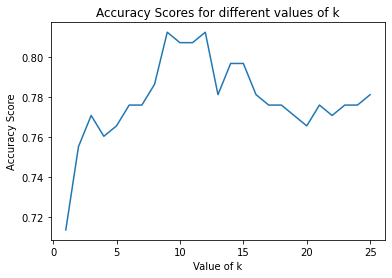

In [9]:
# checking accuracy score for k-value rangin from 1 to 26
k_range = list(range(1,26))
scores = []

# model fitting and calculating accuracy score
# for each k-value in the range 1-26
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    scores.append(metrics.accuracy_score(y_test, y_pred))
    
plt.plot(k_range, scores)
plt.xlabel('Value of k')
plt.ylabel('Accuracy Score')
plt.title('Accuracy Scores for different values of k')
plt.show()

From the plot, we can select k = 9 for a better accuracy

#### better knn model with k = 9

In [10]:
#Create KNN Classifier
knn = KNeighborsClassifier(n_neighbors=9)

#Train the model using the training sets
knn.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = knn.predict(X_test)

In [11]:
# Model Accuracy, how often is the classifier correct when k = 9?
print("Knn Accuracy with k = 9 is :",metrics.accuracy_score(y_test, y_pred))

Knn Accuracy with k = 9 is : 0.8125


## Naïve Bayes



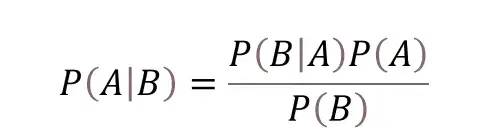

Naive Bayes is a statistical classification technique based on Bayes Theorem. It is one of the simplest supervised learning algorithms. Naive Bayes classifier is the fast, accurate and reliable algorithm. Naive Bayes classifiers have high accuracy and speed on large datasets.

Naive Bayes classifier assumes that the effect of a particular feature in a class is independent of other features.

Naive → It is called naive because it assumes that all features in the dataset are mutually independent.

Bayes, → It is based on Bayes Theorem.

Best used for: 
* Large datasets and low computation capabilities 
* Fast and Accurate predictions
* multi-class prediction problems.

### Naive Bayes using scikit-learn

First, import the naive_bayes module and create GaussianNB classifier

In [12]:
#Import Gaussian Naive Bayes model
from sklearn.naive_bayes import GaussianNB

#Create a Gaussian Classifier
gnb = GaussianNB()

#Train the model using the training sets
gnb.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = gnb.predict(X_test)

In [13]:
# Model Accuracy, how often is the classifier correct?
print("Naive Bayes Accuracy:",metrics.accuracy_score(y_test, y_pred))

Naive Bayes Accuracy: 0.8177083333333334


## Support Vector Machine 

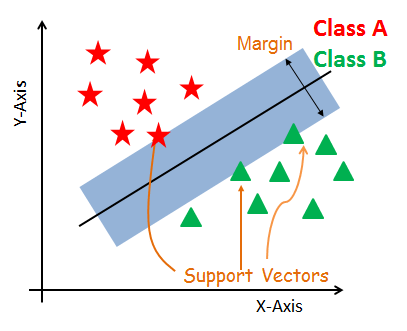

Support vector machine is known for its kernel trick to handle nonlinear input spaces. SVM is in charge of building a hyperplane or set of hyperplanes in a high or infinite-dimensional space, which, in turn, can be used for classification, regression, or other tasks like outliers detection.

Intuitively, a good separation is achieved by the hyperplane with the most significant distance to the nearest training-data point of any class (so-called functional margin) since, in general, the larger the margin, the lower the generalization error of the classifier

Best used for: 
* Complex Non-linear classification
* Multi-Class classification
* Clear margin of separation and with high dimensional space.

### SVM using scikit-learn

First, import the SVM module and create support vector classifier object by passing argument kernel as the linear kernel in SVC() function.

Then, fit your model on the train set using fit() and perform prediction on the test set using predict().

In [14]:
#Import svm model
from sklearn import svm

#Create a svm Classifier
clf = svm.SVC(kernel= 'linear',random_state = 10) # Linear Kernel

#Train the model using the training sets
clf.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

In [15]:
# Model Accuracy: how often is the classifier correct?
print("SVM with a linear kernel Accuracy:",metrics.accuracy_score(y_test, y_pred))

SVM with a linear kernel Accuracy: 0.8229166666666666


The SVM model can be improved by tuning its main hyperparameters, which are: 

* Kernel (linear, rbf, poly,...etc)
* C: Regularization parameter. The strength of the regularization is
inversely proportional to C. Must be strictly positive. The penalty
is a squared l2 penalty.
* Gamma: kernel coafficient, lower value of Gamma will loosely fit the training dataset, whereas a higher value of gamma will exactly fit the training dataset, which causes over-fitting

SVM is not suitable for large datasets because of its high training time. However, it has one of the fastest prediction times